In [12]:
import numpy as np
import matplotlib.pyplot as plt
from prepare_data import main as load_data

ctx = load_data("MEX", keep_top=50, end_buffer=3, filter_active=True)

In [13]:
obs_b = ctx["obs_bundles"]
sizes = obs_b.sum(axis=1)

print(f"N = {len(sizes)} observations")
print(f"M = {ctx['M']} destinations")
print(f"mean = {sizes.mean():.2f}")
print(f"median = {np.median(sizes):.0f}")
print(f"max = {sizes.max()}")
print(f"% with 0 items = {(sizes == 0).mean()*100:.1f}%")
print(f"% with 1 item  = {(sizes == 1).mean()*100:.1f}%")
print(f"% with <=2     = {(sizes <= 2).mean()*100:.1f}%")

N = 157454 observations
M = 50 destinations
mean = 0.97
median = 1
max = 43
% with 0 items = 29.9%
% with 1 item  = 60.5%
% with <=2     = 95.6%


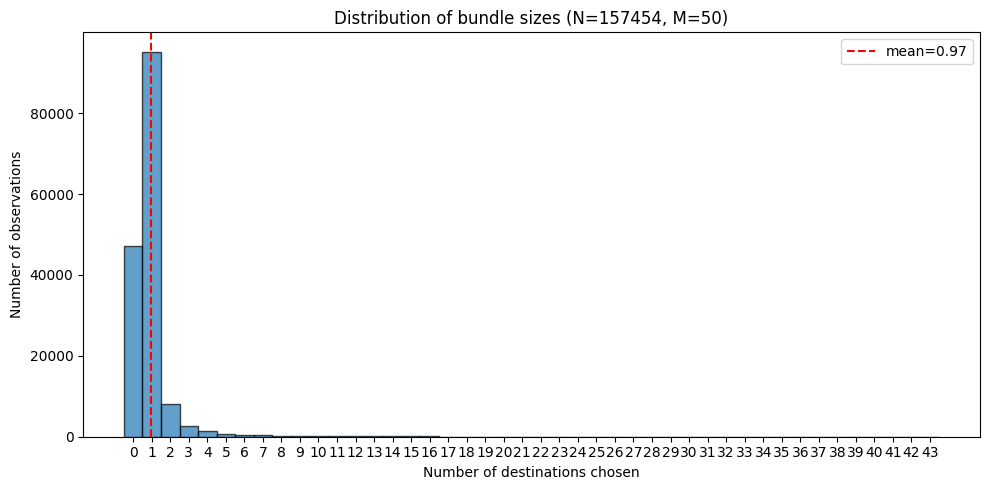

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(-0.5, sizes.max() + 1.5, 1)
ax.hist(sizes, bins=bins, edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of destinations chosen')
ax.set_ylabel('Number of observations')
ax.set_title(f'Distribution of bundle sizes (N={len(sizes)}, M={ctx["M"]})')
ax.set_xticks(range(0, int(sizes.max()) + 1))
ax.axvline(sizes.mean(), color='red', linestyle='--', label=f'mean={sizes.mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# Check: for every year, is every destination chosen by at least one firm?
obs_b = ctx["obs_bundles"]
year_idx = ctx["year_idx"]
unique_years = np.unique(year_idx)

all_covered = True
for yi in unique_years:
    mask = year_idx == yi
    chosen = obs_b[mask].any(axis=0)
    n_chosen = chosen.sum()
    n_missing = ctx["M"] - n_chosen
    if n_missing > 0:
        missing_dests = np.array(ctx["destinations"])[~chosen]
        print(f"Year idx {yi}: {n_chosen}/{ctx['M']} destinations covered, "
              f"MISSING: {list(missing_dests)}")
        all_covered = False
    else:
        print(f"Year idx {yi}: all {ctx['M']} destinations covered "
              f"({mask.sum()} obs)")

if all_covered:
    print(f"\nAll destinations chosen by at least one firm in every year.")
else:
    print(f"\nSome destinations are NOT chosen in some years.")

Year idx 1: all 50 destinations covered (13292 obs)
Year idx 2: all 50 destinations covered (23804 obs)
Year idx 3: all 50 destinations covered (24427 obs)
Year idx 4: all 50 destinations covered (28125 obs)
Year idx 5: all 50 destinations covered (33072 obs)
Year idx 6: all 50 destinations covered (34734 obs)

All destinations chosen by at least one firm in every year.


In [16]:
# How often does a firm export nothing for 2+ years then export again?
# A "gap" = obs where state is empty (no exports last period) but it's not the entry year.
# We detect this by: state_chars all zero AND obs_bundles has exports AND it's not the
# first observation of that firm.
obs_b = ctx["obs_bundles"]
state = ctx["state_chars"]
firm_idx = ctx["firm_idx"]

has_exports_now = obs_b.any(axis=1)
empty_state = ~state.any(axis=1)

# Find each firm's first observation index
first_obs = np.zeros(len(obs_b), dtype=bool)
seen = set()
for i in range(len(obs_b)):
    fi = firm_idx[i]
    if fi not in seen:
        first_obs[i] = True
        seen.add(fi)

# Gap = empty state, not entry year, currently exports something
gap = empty_state & ~first_obs & has_exports_now
# Inactive = empty state, not entry year, doesn't export either
inactive = empty_state & ~first_obs & ~has_exports_now

n_total = len(obs_b)
n_entry = first_obs.sum()
n_active = (~empty_state & ~first_obs).sum()  # has previous exports
n_gap = gap.sum()
n_inactive = inactive.sum()

print(f"Total obs: {n_total}")
print(f"  Entry year obs:     {n_entry} ({n_entry/n_total*100:.1f}%)")
print(f"  Active (state>0):   {n_active} ({n_active/n_total*100:.1f}%)")
print(f"  Inactive, no gap:   {n_inactive} ({n_inactive/n_total*100:.1f}%)")
print(f"  Gap (re-entry):     {n_gap} ({n_gap/n_total*100:.1f}%)")
print(f"\nfilter_active=True would drop: {n_inactive + n_gap} inactive+gap obs")
print(f"  of which {n_gap} are re-entries (export after 0-state)")

Total obs: 157454
  Entry year obs:     66219 (42.1%)
  Active (state>0):   91235 (57.9%)
  Inactive, no gap:   0 (0.0%)
  Gap (re-entry):     0 (0.0%)

filter_active=True would drop: 0 inactive+gap obs
  of which 0 are re-entries (export after 0-state)


Number of firms: 66219
mean max dests = 1.31
median = 1
max = 43
% with max=0  = 0.0%
% with max=1  = 87.6%
% with max<=2 = 94.6%
% with max>=5 = 2.0%
% with max>=10 = 0.6%


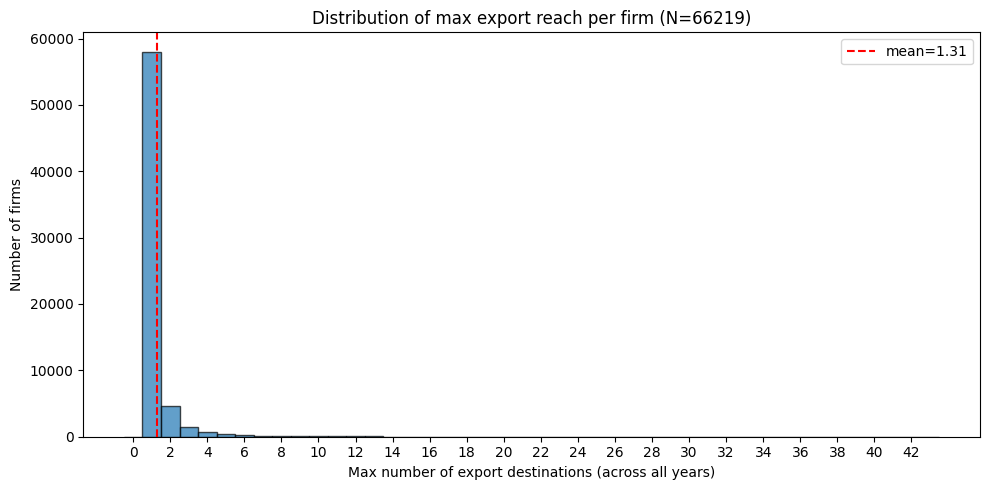

In [17]:
# Distribution of max number of export destinations per firm (across all years)
obs_b = ctx["obs_bundles"]
firm_idx = ctx["firm_idx"]
sizes = obs_b.sum(axis=1)

unique_firms = np.unique(firm_idx)
max_dests = np.array([sizes[firm_idx == fi].max() for fi in unique_firms])

print(f"Number of firms: {len(max_dests)}")
print(f"mean max dests = {max_dests.mean():.2f}")
print(f"median = {np.median(max_dests):.0f}")
print(f"max = {max_dests.max()}")
print(f"% with max=0  = {(max_dests == 0).mean()*100:.1f}%")
print(f"% with max=1  = {(max_dests == 1).mean()*100:.1f}%")
print(f"% with max<=2 = {(max_dests <= 2).mean()*100:.1f}%")
print(f"% with max>=5 = {(max_dests >= 5).mean()*100:.1f}%")
print(f"% with max>=10 = {(max_dests >= 10).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(-0.5, max_dests.max() + 1.5, 1)
ax.hist(max_dests, bins=bins, edgecolor='black', alpha=0.7)
ax.set_xlabel('Max number of export destinations (across all years)')
ax.set_ylabel('Number of firms')
ax.set_title(f'Distribution of max export reach per firm (N={len(max_dests)})')
ax.set_xticks(range(0, int(max_dests.max()) + 1, 2))
ax.axvline(max_dests.mean(), color='red', linestyle='--', label=f'mean={max_dests.mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()